<a href="https://colab.research.google.com/github/ajaykumar080286/feature_engineering/blob/main/23_imputing_numerical_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [24]:
df=pd.read_csv("https://raw.githubusercontent.com/ajaykumar080286/feature_engineering/main/titanic_toy.csv")

In [25]:
df.head(4)

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1


In [26]:
X=df.iloc[:,0:3]
y=df.iloc[:,-1]

In [27]:
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.2, random_state=42)

In [34]:
X_train["Age_mean"] = X_train["Age"].fillna(X_train["Age"].mean())
X_train["Age_median"] = X_train["Age"].fillna(X_train["Age"].median())

X_train["Fare_mean"] = X_train["Fare"].fillna(X_train["Fare"].mean())
X_train["Fare_median"] = X_train["Fare"].fillna(X_train["Fare"].median())

In [35]:
print("Orinal Age", X_train["Age"].var())
print("After Mean Age", X_train["Age_mean"].var())
print("After Median Age", X_train["Age_median"].var())

print("Orinal Fare", X_train["Fare"].var())
print("After Mean fare", X_train["Fare_mean"].var())
print("After Median fare", X_train["Fare_median"].var())


Orinal Age 210.2517072477438
After Mean Age 168.8519336687225
After Median Age 169.20731007048096
Orinal Fare 2761.031434948639
After Mean fare 2621.2323749512393
After Median fare 2637.01248167777


<Axes: ylabel='Density'>

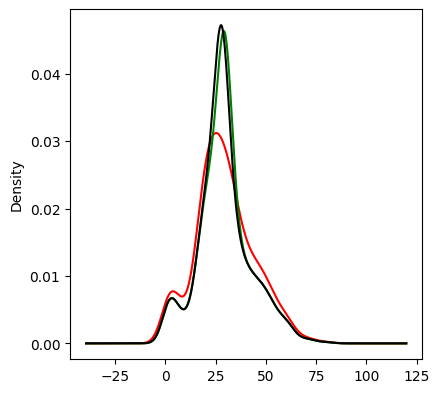

In [44]:
fig=plt.figure(figsize=(10,10))
ax=fig.add_subplot(222)

X_train["Age"].plot.density(ax=ax, color="red")
X_train["Age_mean"].plot.density(ax=ax, color="green")
X_train["Age_median"].plot.density(ax=ax, color="black")




<Axes: ylabel='Density'>

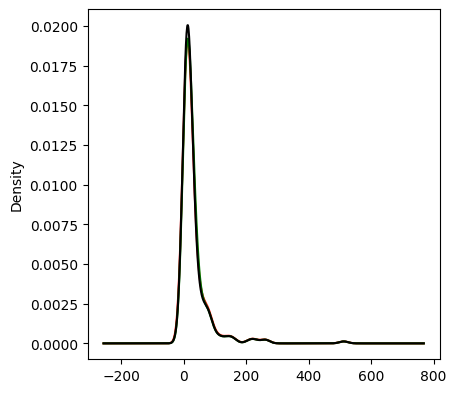

In [45]:
fig=plt.figure(figsize=(10,10))
ax=fig.add_subplot(222)

X_train["Fare"].plot.density(ax=ax, color="red")
X_train["Fare_mean"].plot.density(ax=ax, color="green")
X_train["Fare_median"].plot.density(ax=ax, color="black")




<Axes: ylabel='Density'>

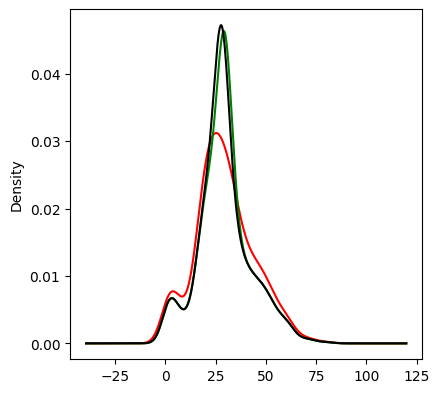

In [47]:
fig=plt.figure(figsize=(10,10))
ax=fig.add_subplot(222)

X_train["Age"].plot(kind="kde",ax=ax, color="red")
X_train["Age_mean"].plot(kind="kde",ax=ax, color="green")
X_train["Age_median"].plot(kind="kde",ax=ax, color="black")




In [56]:
column_tranfer=ColumnTransformer([
    ("trf1", SimpleImputer(strategy="mean"), ["Age"]),
    ("trf2", SimpleImputer(strategy="median"), ["Fare"])
], remainder="passthrough")

In [58]:
X_train_trf=column_tranfer.fit_transform(X_train)
X_test_trf=column_tranfer.fit_transform(X_test)

In [64]:
df1=pd.DataFrame(X_train_trf,columns=X_train.columns)

In [65]:
df1

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
0,45.500000,28.5000,0.0,45.500000,45.5,28.500000,28.5000
1,23.000000,13.0000,0.0,23.000000,23.0,13.000000,13.0000
2,32.000000,7.9250,0.0,32.000000,32.0,7.925000,7.9250
3,26.000000,7.8542,1.0,26.000000,26.0,7.854200,7.8542
4,6.000000,31.2750,6.0,6.000000,6.0,31.275000,31.2750
...,...,...,...,...,...,...,...
707,21.000000,7.6500,0.0,21.000000,21.0,7.650000,7.6500
708,29.498846,31.0000,0.0,29.498846,28.0,31.000000,31.0000
709,41.000000,14.4000,2.0,41.000000,41.0,32.517788,14.4000
710,14.000000,120.0000,3.0,14.000000,14.0,120.000000,120.0000
